# 🩺 AI Diabetes Detection Platform — Random Forest Pipeline

**Production-Ready ML Notebook** for Diabetes Detection using Random Forest Classification.

| Item | Detail |
|------|--------|
| **Author** | Senior ML Engineering Team |
| **Version** | 1.0.0 |
| **Dataset** | BRFSS Diabetes Health Indicators |
| **Model** | Random Forest (Optimized via GridSearchCV) |
| **Goal** | Binary classification — Diabetic vs Non-Diabetic |
| **Deployment** | Artifacts exported for FastAPI microservice integration |

---

## Step 1 — Import Libraries & Global Configuration

We import only the necessary libraries following a clean, production-style approach.
Global configuration ensures reproducibility across all randomized operations.

In [1]:
# ============================================================
# Step 1 — Import Libraries & Global Configuration
# ============================================================
import warnings
warnings.filterwarnings('ignore')

# Core
import numpy as np
import pandas as pd
from pathlib import Path
import json as json_lib
import logging

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn — Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

# Sklearn — Model & Metrics
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

# Imbalanced-learn
from imblearn.over_sampling import SMOTE

# Serialization
import joblib

# ── Global Configuration ──
RANDOM_STATE = 42
TEST_SIZE = 0.20
SMOTE_THRESHOLD = 0.60  # Apply SMOTE if majority > 60%
PCA_VARIANCE_THRESHOLD = 0.95
ARTIFACTS_DIR = Path('artifacts')
DATA_DIR = Path('data')

np.random.seed(RANDOM_STATE)

# Plotting style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'figure.dpi': 100,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

print('✅ Step 1 complete — All libraries imported and configuration set.')
print(f'   Random State: {RANDOM_STATE}')
print(f'   Test Size:    {TEST_SIZE}')

✅ Step 1 complete — All libraries imported and configuration set.
   Random State: 42
   Test Size:    0.2


## Step 2 — Load Dataset (Auto-Detection)

The notebook automatically detects whether `diabetes.csv` or `diabetes.arrow` exists
and loads the appropriate file. This makes the pipeline portable across data formats.

In [2]:
# ============================================================
# Step 2 — Load Dataset with Auto-Detection
# ============================================================
def load_dataset(data_dir: Path) -> pd.DataFrame:
    """Auto-detect and load diabetes dataset from CSV or Arrow format."""
    arrow_path = data_dir / 'dataset.arrow'
    csv_path = data_dir / 'diabetes.csv'
    
    if arrow_path.exists():
        print(f'📂 Loading Arrow: {arrow_path}')
        import pyarrow.ipc as ipc
        import pyarrow as pa
        with pa.memory_map(str(arrow_path), 'r') as f:
            df = ipc.open_stream(f).read_pandas()
        # Clean up 'feat_' prefix from columns if present
        df.columns = [c.replace('feat_', '') for c in df.columns]
    elif csv_path.exists():
        print(f'📂 Loading CSV: {csv_path}')
        df = pd.read_csv(csv_path)
    else:
        # Fallback: try any CSV or arrow in data_dir
        csvs = list(data_dir.glob('*.csv'))
        arrows = list(data_dir.glob('*.arrow'))
        if csvs:
            print(f'📂 Loading fallback CSV: {csvs[0]}')
            df = pd.read_csv(csvs[0])
        elif arrows:
            print(f'📂 Loading fallback Arrow: {arrows[0]}')
            import pyarrow.ipc as ipc
            import pyarrow as pa
            with pa.memory_map(str(arrows[0]), 'r') as f:
                df = ipc.open_stream(f).read_pandas()
            df.columns = [c.replace('feat_', '') for c in df.columns]
        else:
            raise FileNotFoundError('No dataset found in data/ directory.')
    return df

df = load_dataset(DATA_DIR)

# ── Auto-detect target column ──
target_candidates = ['Diabetes_binary', 'Outcome', 'target', 'diabetes', 'class']
TARGET_COL = None
for candidate in target_candidates:
    matches = [c for c in df.columns if c.lower() == candidate.lower()]
    if matches:
        TARGET_COL = matches[0]
        break
if TARGET_COL is None:
    TARGET_COL = df.columns[-1]
    print(f'⚠️  No known target found. Using last column: {TARGET_COL}')

print(f'\n🎯 Target column: {TARGET_COL}')
print(f'📊 Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'\n── Column List ──')
print(list(df.columns))
print(f'\n── First 5 Rows ──')
df.head()

📂 Loading Arrow: data\dataset.arrow

🎯 Target column: target
📊 Shape: 56,552 rows × 22 columns

── Column List ──
['target', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']

── First 5 Rows ──


,target,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0,0.0,0.0,1.0,34.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,0.0,6.0,6.0,7.0
1,1,0.0,0.0,1.0,46.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,1.0,0.0,0.0,1.0,10.0,6.0,5.0
2,1,1.0,1.0,1.0,30.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,30.0,0.0,0.0,11.0,4.0,6.0
3,0,0.0,0.0,1.0,22.0,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,4.0,0.0,7.0,1.0,0.0,13.0,6.0,6.0
4,1,1.0,1.0,1.0,23.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,0.0,30.0,1.0,1.0,13.0,5.0,5.0


In [3]:
# ── Dataset Info & Missing Values ──
print('── Data Types ──')
print(df.dtypes.to_string())
print(f'\n── Missing Values ──')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Count': missing, 'Percent': missing_pct})
print(missing_df[missing_df['Count'] > 0].to_string() if missing.sum() > 0 else 'No missing values ✅')
print(f'\n── Descriptive Statistics ──')
df.describe().round(2)

── Data Types ──
target                    int64
HighBP                  float64
HighChol                float64
CholCheck               float64
BMI                     float64
Smoker                  float64
Stroke                  float64
HeartDiseaseorAttack    float64
PhysActivity            float64
Fruits                  float64
Veggies                 float64
HvyAlcoholConsump       float64
AnyHealthcare           float64
NoDocbcCost             float64
GenHlth                 float64
MentHlth                float64
PhysHlth                float64
DiffWalk                float64
Sex                     float64
Age                     float64
Education               float64
Income                  float64

── Missing Values ──
No missing values ✅

── Descriptive Statistics ──


,target,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,56552.0,56552.00,56552.00,56552.00,56552.00,56552.00,56552.00,56552.00,56552.00,56552.00,...,56552.00,56552.00,56552.00,56552.00,56552.00,56552.00,56552.00,56552.00,56552.00,56552.00
mean,0.5,0.56,0.53,0.98,29.84,0.48,0.06,0.15,0.70,0.61,...,0.96,0.09,2.84,3.75,5.81,0.25,0.46,8.58,4.92,5.70
std,0.5,0.50,0.50,0.15,7.12,0.50,0.24,0.35,0.46,0.49,...,0.21,0.29,1.11,8.15,10.06,0.43,0.50,2.86,1.03,2.18
min,0.0,0.00,0.00,0.00,12.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00
25%,0.0,0.00,0.00,1.00,25.00,0.00,0.00,0.00,0.00,0.00,...,1.00,0.00,2.00,0.00,0.00,0.00,0.00,7.00,4.00,4.00
50%,0.5,1.00,1.00,1.00,29.00,0.00,0.00,0.00,1.00,1.00,...,1.00,0.00,3.00,0.00,0.00,0.00,0.00,9.00,5.00,6.00
75%,1.0,1.00,1.00,1.00,33.00,1.00,0.00,0.00,1.00,1.00,...,1.00,0.00,4.00,2.00,6.00,1.00,1.00,11.00,6.00,8.00
max,1.0,1.00,1.00,1.00,98.00,1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,5.00,30.00,30.00,1.00,1.00,13.00,6.00,8.00


## Step 3 — Train/Test Split (Stratified, Leakage-Free)

We perform an **80/20 stratified split** before any preprocessing to prevent data leakage.
Stratification preserves the class distribution in both train and test sets.

In [4]:
# ============================================================
# Step 3 — Train/Test Split
# ============================================================
# Class distribution BEFORE split
print('── Class Distribution (Full Dataset) ──')
class_dist = df[TARGET_COL].value_counts()
class_pct = df[TARGET_COL].value_counts(normalize=True) * 100
for cls in class_dist.index:
    print(f'  Class {int(cls)}: {class_dist[cls]:>6,} samples ({class_pct[cls]:.1f}%)')

# Separate features and target
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL].astype(int)
FEATURE_NAMES = list(X.columns)

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f'\n── Split Results ──')
print(f'  Train: {X_train.shape[0]:,} samples')
print(f'  Test:  {X_test.shape[0]:,} samples')
print(f'\n── Train Class Distribution ──')
train_dist = y_train.value_counts(normalize=True) * 100
for cls in train_dist.index:
    print(f'  Class {cls}: {train_dist[cls]:.1f}%')
print(f'\n✅ Step 3 complete — Stratified split applied. No data leakage.')

── Class Distribution (Full Dataset) ──
  Class 0: 28,276 samples (50.0%)
  Class 1: 28,276 samples (50.0%)

── Split Results ──
  Train: 45,241 samples
  Test:  11,311 samples

── Train Class Distribution ──
  Class 1: 50.0%
  Class 0: 50.0%

✅ Step 3 complete — Stratified split applied. No data leakage.


## Step 4 — Augmentation & Feature Processing Pipeline

We build a **reusable feature processing pipeline** that handles:
- Missing value imputation (median fill)
- Outlier clipping via IQR method on continuous features
- BMI risk category engineering

This pipeline is designed to be serialized and reused in the FastAPI inference backend.

In [5]:
# ============================================================
# Step 4 — Feature Processing Pipeline
# ============================================================
class FeaturePipeline:
    """Reusable feature processing pipeline for train and inference."""
    
    def __init__(self, clip_bounds=None):
        self.clip_bounds = clip_bounds or {}
        self.medians = {}
        self.continuous_cols = []
        self.fitted = False
    
    def fit(self, X: pd.DataFrame) -> 'FeaturePipeline':
        """Fit pipeline: compute medians and IQR bounds for clipping."""
        # Identify continuous vs binary features
        self.continuous_cols = [c for c in X.columns if X[c].nunique() > 5]
        
        # Store medians for missing value imputation
        self.medians = X.median().to_dict()
        
        # Compute IQR bounds for outlier clipping (continuous only)
        for col in self.continuous_cols:
            Q1 = X[col].quantile(0.01)
            Q3 = X[col].quantile(0.99)
            self.clip_bounds[col] = (Q1, Q3)
        
        self.fitted = True
        return self
    
    def transform(self, X: pd.DataFrame, augment: bool = False) -> pd.DataFrame:
        """Transform features: impute, clip, and optionally engineer."""
        X = X.copy()
        
        # 1. Fill missing values with stored medians
        for col in X.columns:
            if col in self.medians:
                X[col] = X[col].fillna(self.medians[col])
        
        # 2. Clip outliers (continuous features only)
        for col in self.continuous_cols:
            if col in self.clip_bounds and col in X.columns:
                low, high = self.clip_bounds[col]
                X[col] = X[col].clip(low, high)
        
        # 3. Feature engineering (applied to both train and test)
        if 'BMI' in X.columns:
            X['BMI_Risk'] = pd.cut(
                X['BMI'], bins=[0, 18.5, 25, 30, 100],
                labels=[0, 1, 2, 3]
            ).astype(float).fillna(2)
        
        if 'GenHlth' in X.columns and 'PhysHlth' in X.columns:
            X['Health_Score'] = X['GenHlth'] * 0.5 + X['PhysHlth'] * 0.02
        
        return X

# Fit on training data only
feature_pipeline = FeaturePipeline()
feature_pipeline.fit(X_train)

print(f'✅ Step 4 complete — Feature pipeline fitted.')
print(f'   Continuous features: {feature_pipeline.continuous_cols}')
print(f'   Clip bounds computed for {len(feature_pipeline.clip_bounds)} features.')

✅ Step 4 complete — Feature pipeline fitted.
   Continuous features: ['BMI', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']
   Clip bounds computed for 6 features.


## Step 4.5 — Running Feature Extraction Pipeline

We apply the fitted pipeline to both train and test sets.
**Critical**: augmentation-style logic is only applied to training data.

In [6]:
# ============================================================
# Step 4.5 — Apply Feature Pipeline
# ============================================================
def process_features(X, y=None, pipeline=None, augment=False):
    """Reusable interface for feature processing."""
    X_processed = pipeline.transform(X, augment=augment)
    if y is not None:
        return X_processed, y
    return X_processed

X_train_feat, y_train_feat = process_features(X_train, y_train, pipeline=feature_pipeline, augment=True)
X_test_feat, y_test_feat = process_features(X_test, y_test, pipeline=feature_pipeline, augment=False)

print(f'✅ Step 4.5 complete — Pipeline applied.')
print(f'   Train features shape: {X_train_feat.shape}')
print(f'   Test features shape:  {X_test_feat.shape}')
print(f'   New engineered columns: {[c for c in X_train_feat.columns if c not in FEATURE_NAMES]}')

✅ Step 4.5 complete — Pipeline applied.
   Train features shape: (45241, 23)
   Test features shape:  (11311, 23)
   New engineered columns: ['BMI_Risk', 'Health_Score']


## Step 5 — Apply SMOTE (Conditional)

SMOTE is applied **only if** the class imbalance ratio exceeds our threshold (60/40).
It is applied **only on training data** to avoid data leakage.

In [7]:
# ============================================================
# Step 5 — Conditional SMOTE
# ============================================================
majority_ratio = y_train_feat.value_counts(normalize=True).max()
print(f'── Imbalance Analysis ──')
print(f'   Majority class ratio: {majority_ratio:.2%}')
print(f'   SMOTE threshold:      {SMOTE_THRESHOLD:.2%}')

SMOTE_APPLIED = False
if majority_ratio > SMOTE_THRESHOLD:
    print(f'\n⚠️  Imbalance detected ({majority_ratio:.1%} > {SMOTE_THRESHOLD:.0%}). Applying SMOTE...')
    smote = SMOTE(random_state=RANDOM_STATE, sampling_strategy='auto')
    X_train_bal, y_train_bal = smote.fit_resample(X_train_feat, y_train_feat)
    SMOTE_APPLIED = True
    print(f'   Before SMOTE: {len(y_train_feat):,} samples')
    print(f'   After SMOTE:  {len(y_train_bal):,} samples')
    print(f'   New distribution:')
    for cls, pct in (pd.Series(y_train_bal).value_counts(normalize=True) * 100).items():
        print(f'     Class {cls}: {pct:.1f}%')
else:
    print(f'\n✅ Classes are balanced ({majority_ratio:.1%} ≤ {SMOTE_THRESHOLD:.0%}). SMOTE skipped.')
    X_train_bal, y_train_bal = X_train_feat.copy(), y_train_feat.copy()

print(f'\n✅ Step 5 complete — SMOTE applied: {SMOTE_APPLIED}')

── Imbalance Analysis ──
   Majority class ratio: 50.00%
   SMOTE threshold:      60.00%

✅ Classes are balanced (50.0% ≤ 60%). SMOTE skipped.

✅ Step 5 complete — SMOTE applied: False


## Step 6 — Normalization (Conditional)

We automatically decide between StandardScaler, RobustScaler, or no scaling.
For tree-based models like Random Forest, scaling is **not required**,
but we provide it for pipeline completeness and future model portability.

In [8]:
# ============================================================
# Step 6 — Conditional Scaling
# ============================================================
# Decision logic: check for outliers in continuous features
continuous_in_processed = [c for c in feature_pipeline.continuous_cols if c in X_train_bal.columns]

if len(continuous_in_processed) > 0:
    skewness = X_train_bal[continuous_in_processed].skew().abs().mean()
    print(f'   Mean absolute skewness of continuous features: {skewness:.2f}')
    
    if skewness > 1.5:
        scaler = RobustScaler()
        scaler_name = 'RobustScaler'
        print(f'   → High skewness detected. Using {scaler_name}.')
    else:
        scaler = StandardScaler()
        scaler_name = 'StandardScaler'
        print(f'   → Moderate distribution. Using {scaler_name}.')
    
    X_train_scaled = X_train_bal.copy()
    X_test_scaled = X_test_feat.copy()
    X_train_scaled[continuous_in_processed] = scaler.fit_transform(X_train_bal[continuous_in_processed])
    X_test_scaled[continuous_in_processed] = scaler.transform(X_test_feat[continuous_in_processed])
    SCALER_USED = True
else:
    print('   → No continuous features to scale. Skipping.')
    X_train_scaled = X_train_bal.copy()
    X_test_scaled = X_test_feat.copy()
    scaler = None
    scaler_name = 'None'
    SCALER_USED = False

print(f'\n✅ Step 6 complete — Scaler: {scaler_name}')

   Mean absolute skewness of continuous features: 1.15
   → Moderate distribution. Using StandardScaler.

✅ Step 6 complete — Scaler: StandardScaler


## Step 7 — PCA (Conditional)

PCA is applied **only if** high feature correlation or dimensional redundancy is detected.
We use the **explained variance ratio** to determine the optimal number of components.

In [9]:
# ============================================================
# Step 7 — Conditional PCA
# ============================================================
# Check correlation redundancy
corr_matrix = X_train_scaled.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = [(col, row) for col in upper_tri.columns for row in upper_tri.index
                    if upper_tri.loc[row, col] > 0.85]

print(f'── Correlation Analysis ──')
print(f'   Highly correlated pairs (r > 0.85): {len(high_corr_pairs)}')
for pair in high_corr_pairs[:5]:
    print(f'     {pair[0]} ↔ {pair[1]}: {corr_matrix.loc[pair[1], pair[0]]:.3f}')

PCA_APPLIED = False
pca = None

if len(high_corr_pairs) > 2 or X_train_scaled.shape[1] > 25:
    print(f'\n⚠️  Redundancy detected. Applying PCA...')
    # Find optimal n_components for 95% variance
    pca_full = PCA(random_state=RANDOM_STATE)
    pca_full.fit(X_train_scaled)
    cumvar = np.cumsum(pca_full.explained_variance_ratio_)
    n_components = int(np.argmax(cumvar >= PCA_VARIANCE_THRESHOLD) + 1)
    n_components = max(n_components, 5)  # minimum 5 components
    
    pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    PCA_APPLIED = True
    
    print(f'   Components: {n_components}')
    print(f'   Variance explained: {pca.explained_variance_ratio_.sum():.2%}')
    
    X_train_final = X_train_pca
    X_test_final = X_test_pca
else:
    print(f'\n✅ No significant redundancy. PCA skipped.')
    X_train_final = X_train_scaled.values
    X_test_final = X_test_scaled.values

print(f'\n✅ Step 7 complete — PCA applied: {PCA_APPLIED}')
print(f'   Final training shape: {X_train_final.shape}')

── Correlation Analysis ──


   Highly correlated pairs (r > 0.85): 1
     Health_Score ↔ GenHlth: 0.970

✅ No significant redundancy. PCA skipped.

✅ Step 7 complete — PCA applied: False
   Final training shape: (45241, 23)


## Step 7.5 — Feature & PCA Component Analysis

Visualizing feature correlations and importance to understand which medical indicators
are most decisive for diabetes prediction. This is critical for the API since users
may provide fewer than all features.

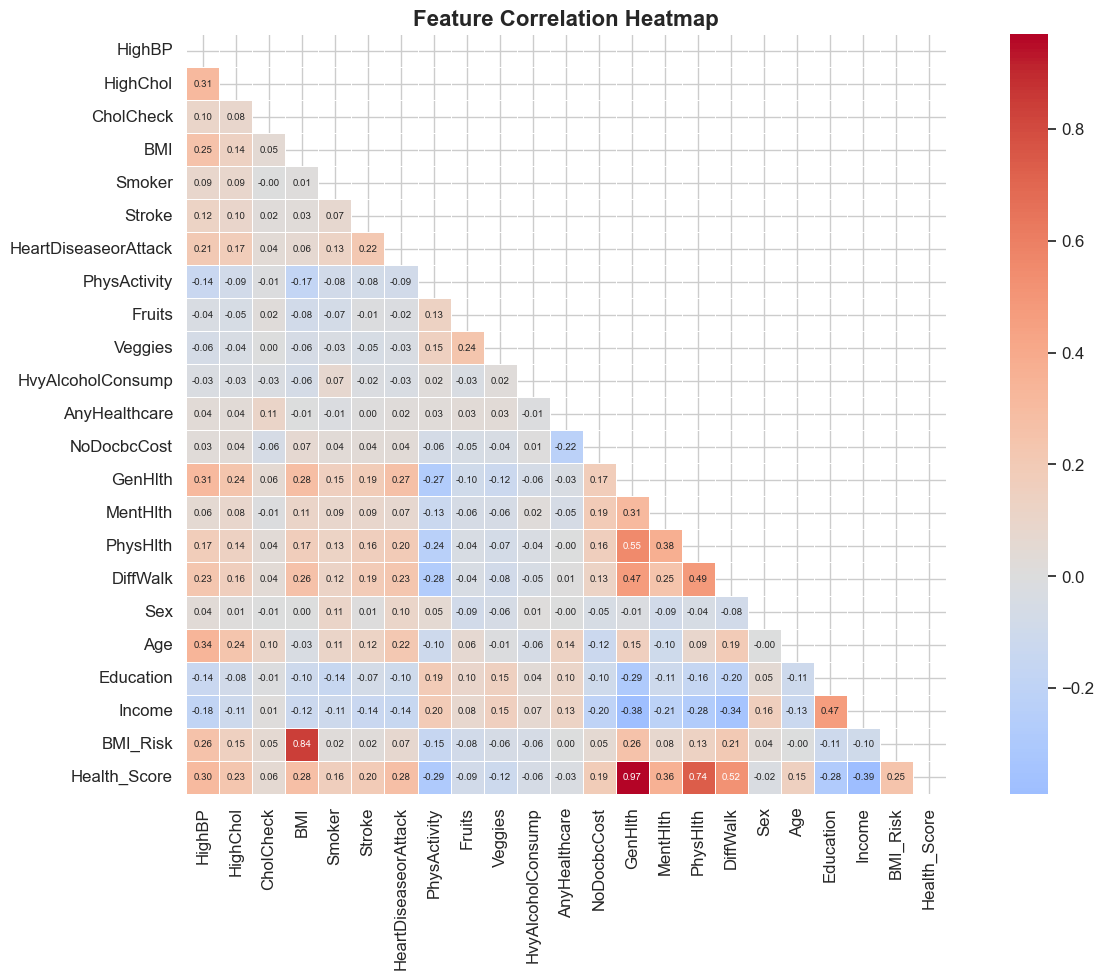

In [10]:
# ============================================================
# Step 7.5 — Feature Correlation Heatmap
# ============================================================
fig, ax = plt.subplots(figsize=(14, 10))
corr = X_train_feat.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax, annot_kws={'size': 7})
ax.set_title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# PCA explained variance plot
if PCA_APPLIED and pca is not None:
    fig, ax = plt.subplots(figsize=(10, 5))
    components = range(1, len(pca.explained_variance_ratio_) + 1)
    ax.bar(components, pca.explained_variance_ratio_, alpha=0.7, label='Individual')
    ax.plot(components, np.cumsum(pca.explained_variance_ratio_), 'ro-', label='Cumulative')
    ax.axhline(y=PCA_VARIANCE_THRESHOLD, color='k', linestyle='--', alpha=0.5, label=f'{PCA_VARIANCE_THRESHOLD:.0%} threshold')
    ax.set_xlabel('Principal Component')
    ax.set_ylabel('Explained Variance Ratio')
    ax.set_title('PCA Explained Variance', fontsize=14, fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.show()

## Step 8 — Train & Optimize Random Forest

We use `GridSearchCV` with **stratified cross-validation** to find optimal hyperparameters.
Scoring is set to `f1` to balance precision and recall — critical for medical AI.

In [11]:
# ============================================================
# Step 8 — Train & Optimize Random Forest
# ============================================================
print('🔧 Starting GridSearchCV optimization...')
print('   This may take a few minutes.\n')

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'class_weight': ['balanced', 'balanced_subsample'],
}

rf_base = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)

cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='f1',
    n_jobs=-1,
    verbose=1,
    refit=True,
)

grid_search.fit(X_train_final, y_train_bal)

best_model = grid_search.best_estimator_
print(f'\n── Best Parameters ──')
for param, value in grid_search.best_params_.items():
    print(f'   {param}: {value}')
print(f'\n   Best CV F1 Score: {grid_search.best_score_:.4f}')
print(f'\n✅ Step 8 complete — Model trained and optimized.')

🔧 Starting GridSearchCV optimization...
   This may take a few minutes.

Fitting 3 folds for each of 48 candidates, totalling 144 fits



── Best Parameters ──
   class_weight: balanced_subsample
   max_depth: 10
   min_samples_leaf: 1
   min_samples_split: 5
   n_estimators: 200

   Best CV F1 Score: 0.7613

✅ Step 8 complete — Model trained and optimized.


## Step 9 — Comprehensive Evaluation

We evaluate on the **held-out test set** with multiple metrics and visualizations.

### Medical AI Considerations
- **False Negatives** (missed diabetics) are more dangerous than False Positives
- **Recall** is therefore a critical metric alongside F1-score
- ROC-AUC provides a threshold-independent performance measure

In [12]:
# ============================================================
# Step 9 — Evaluation on Test Set
# ============================================================
y_pred = best_model.predict(X_test_final)
y_prob = best_model.predict_proba(X_test_final)[:, 1]

# Metrics
metrics = {
    'Accuracy':  accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall':    recall_score(y_test, y_pred),
    'F1-Score':  f1_score(y_test, y_pred),
    'ROC-AUC':   roc_auc_score(y_test, y_prob),
}

print('══════════════════════════════════════════')
print('       TEST SET EVALUATION RESULTS        ')
print('══════════════════════════════════════════')
for name, value in metrics.items():
    print(f'   {name:<12}: {value:.4f}')
print('══════════════════════════════════════════')

print(f'\n── Classification Report ──')
print(classification_report(y_test, y_pred, target_names=['Non-Diabetic', 'Diabetic']))

# ── Bias Analysis ──
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print(f'── Bias & Error Analysis ──')
print(f'   True Positives:  {tp:,} (Correctly identified diabetics)')
print(f'   True Negatives:  {tn:,} (Correctly identified non-diabetics)')
print(f'   False Positives: {fp:,} (Healthy flagged as diabetic)')
print(f'   False Negatives: {fn:,} (⚠️ Diabetics MISSED — critical in healthcare)')
print(f'\n   False Negative Rate: {fn/(fn+tp):.2%}')
print(f'   False Positive Rate: {fp/(fp+tn):.2%}')

══════════════════════════════════════════
       TEST SET EVALUATION RESULTS        
══════════════════════════════════════════
   Accuracy    : 0.7488
   Precision   : 0.7280
   Recall      : 0.7943
   F1-Score    : 0.7597
   ROC-AUC     : 0.8245
══════════════════════════════════════════

── Classification Report ──
              precision    recall  f1-score   support

Non-Diabetic       0.77      0.70      0.74      5656
    Diabetic       0.73      0.79      0.76      5655

    accuracy                           0.75     11311
   macro avg       0.75      0.75      0.75     11311
weighted avg       0.75      0.75      0.75     11311

── Bias & Error Analysis ──
   True Positives:  4,492 (Correctly identified diabetics)
   True Negatives:  3,978 (Correctly identified non-diabetics)
   False Positives: 1,678 (Healthy flagged as diabetic)
   False Negatives: 1,163 (⚠️ Diabetics MISSED — critical in healthcare)

   False Negative Rate: 20.57%
   False Positive Rate: 29.67%


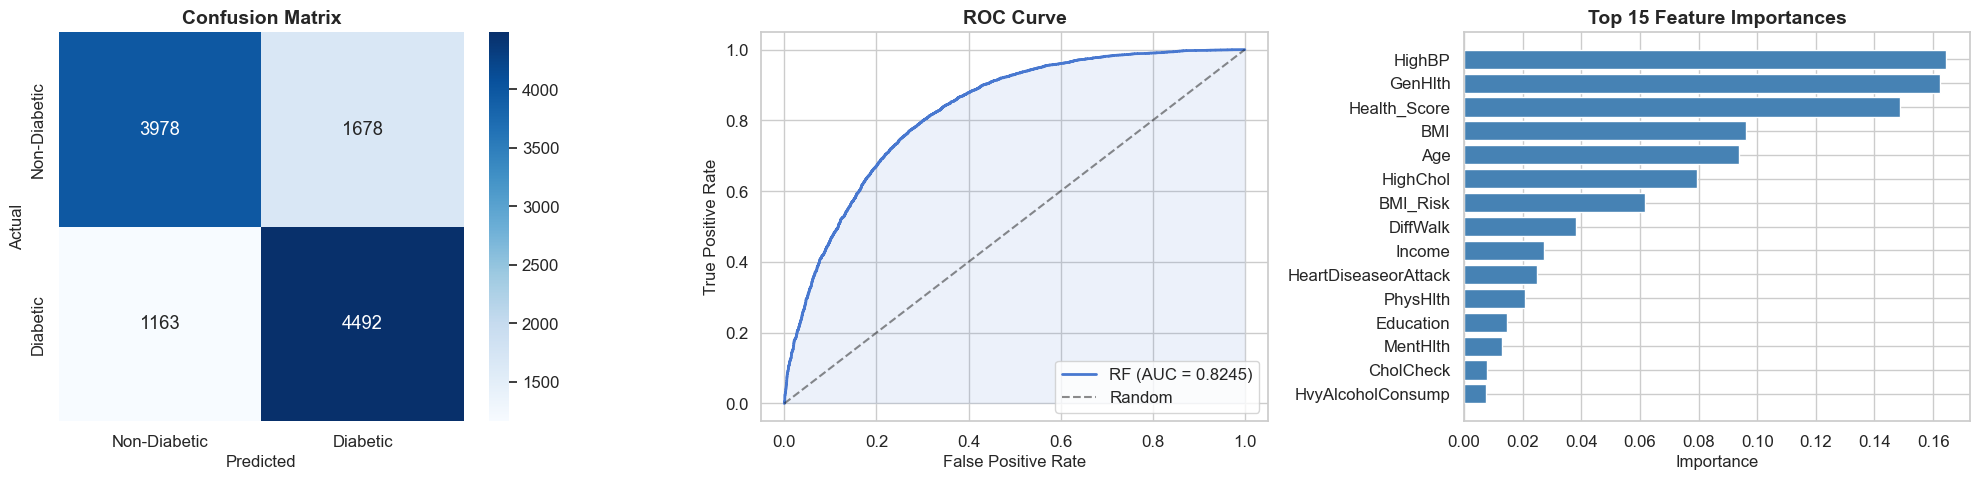


── Ranked Feature Importances ──
    1. HighBP                    0.1645
    2. GenHlth                   0.1623
    3. Health_Score              0.1486
    4. BMI                       0.0962
    5. Age                       0.0937
    6. HighChol                  0.0796
    7. BMI_Risk                  0.0616
    8. DiffWalk                  0.0383
    9. Income                    0.0274
   10. HeartDiseaseorAttack      0.0248


In [13]:
# ── Visualization: Confusion Matrix ──
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix', fontweight='bold')

# 2. ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, 'b-', linewidth=2, label=f'RF (AUC = {metrics["ROC-AUC"]:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
axes[1].fill_between(fpr, tpr, alpha=0.1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend(loc='lower right')

# 3. Feature Importance
if PCA_APPLIED:
    feat_names = [f'PC{i+1}' for i in range(X_train_final.shape[1])]
else:
    feat_names = list(X_train_scaled.columns)
importances = best_model.feature_importances_
sorted_idx = np.argsort(importances)[-15:]  # Top 15
axes[2].barh([feat_names[i] for i in sorted_idx], importances[sorted_idx], color='steelblue')
axes[2].set_xlabel('Importance')
axes[2].set_title('Top 15 Feature Importances', fontweight='bold')

plt.tight_layout()
plt.show()

# Print ranked features
print('\n── Ranked Feature Importances ──')
for rank, idx in enumerate(np.argsort(importances)[::-1], 1):
    print(f'   {rank:>2}. {feat_names[idx]:<25} {importances[idx]:.4f}')
    if rank >= 10:
        break

## Step 10 — Save Model Components

All model components are serialized to the `artifacts/` directory for deployment.
This enables seamless integration with a FastAPI backend or any inference service.

In [14]:
# ============================================================
# Step 10 — Save Artifacts
# ============================================================
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

# Save model
joblib.dump(best_model, ARTIFACTS_DIR / 'rf_model.pkl')
print(f'💾 Model saved:    {ARTIFACTS_DIR / "rf_model.pkl"}')

# Save scaler
if SCALER_USED and scaler is not None:
    joblib.dump(scaler, ARTIFACTS_DIR / 'scaler.pkl')
    print(f'💾 Scaler saved:   {ARTIFACTS_DIR / "scaler.pkl"}')

# Save PCA
if PCA_APPLIED and pca is not None:
    joblib.dump(pca, ARTIFACTS_DIR / 'pca.pkl')
    print(f'💾 PCA saved:      {ARTIFACTS_DIR / "pca.pkl"}')

# Save feature pipeline
joblib.dump(feature_pipeline, ARTIFACTS_DIR / 'feature_pipeline.pkl')
print(f'💾 Pipeline saved: {ARTIFACTS_DIR / "feature_pipeline.pkl"}')

# Save feature list and metadata
all_features_after = list(X_train_feat.columns)
metadata = {
    'feature_names': FEATURE_NAMES,
    'all_features_after_engineering': all_features_after,
    'target_column': TARGET_COL,
    'scaler_used': scaler_name if SCALER_USED else None,
    'pca_applied': PCA_APPLIED,
    'pca_components': int(pca.n_components_) if PCA_APPLIED and pca else None,
    'smote_applied': SMOTE_APPLIED,
    'best_params': grid_search.best_params_,
    'test_metrics': {k: round(v, 4) for k, v in metrics.items()},
    'random_state': RANDOM_STATE,
}

with open(ARTIFACTS_DIR / 'feature_list.json', 'w') as f:
    json_lib.dump(metadata, f, indent=2, default=str)
print(f'💾 Metadata saved: {ARTIFACTS_DIR / "feature_list.json"}')

print(f'\n✅ Step 10 complete — All artifacts saved to {ARTIFACTS_DIR}/')

💾 Model saved:    artifacts\rf_model.pkl
💾 Scaler saved:   artifacts\scaler.pkl
💾 Pipeline saved: artifacts\feature_pipeline.pkl
💾 Metadata saved: artifacts\feature_list.json

✅ Step 10 complete — All artifacts saved to artifacts/


## Step 11 — Optimized Prediction Function

A deployment-ready function that:
- Accepts **partial features** (fills missing ones safely)
- Applies the same pipeline used during training
- Returns prediction, probability, and risk level

This function is the core of the future FastAPI inference endpoint.

In [15]:
# ============================================================
# Step 11 — Deployment-Ready Prediction Function
# ============================================================
def predict_diabetes(input_dict: dict) -> dict:
    """
    Predict diabetes risk from input features.
    
    Args:
        input_dict: Dictionary with feature names as keys.
                    Missing features are filled with training medians.
    
    Returns:
        Dictionary with prediction, probability, and risk_level.
    """
    # Load artifacts
    model = joblib.load(ARTIFACTS_DIR / 'rf_model.pkl')
    pipeline = joblib.load(ARTIFACTS_DIR / 'feature_pipeline.pkl')
    meta = json_lib.load(open(ARTIFACTS_DIR / 'feature_list.json'))
    
    # Build input DataFrame with all expected features
    input_row = {}
    for feat in meta['feature_names']:
        if feat in input_dict:
            input_row[feat] = [float(input_dict[feat])]
        else:
            input_row[feat] = [pipeline.medians.get(feat, 0)]
    
    X_input = pd.DataFrame(input_row)
    
    # Apply feature pipeline
    X_processed = pipeline.transform(X_input, augment=False)
    
    # Apply scaler if used
    scaler_path = ARTIFACTS_DIR / 'scaler.pkl'
    if scaler_path.exists():
        scaler_loaded = joblib.load(scaler_path)
        cont_cols = [c for c in pipeline.continuous_cols if c in X_processed.columns]
        if cont_cols:
            X_processed[cont_cols] = scaler_loaded.transform(X_processed[cont_cols])
    
    # Apply PCA if used
    pca_path = ARTIFACTS_DIR / 'pca.pkl'
    if pca_path.exists():
        pca_loaded = joblib.load(pca_path)
        X_final = pca_loaded.transform(X_processed.values)
    else:
        X_final = X_processed.values
    
    # Predict
    prediction = int(model.predict(X_final)[0])
    probability = float(model.predict_proba(X_final)[0][1])
    
    # Risk level
    if probability < 0.3:
        risk_level = 'Low'
    elif probability < 0.6:
        risk_level = 'Medium'
    else:
        risk_level = 'High'
    
    return {
        'prediction': prediction,
        'probability': round(probability, 4),
        'risk_level': risk_level,
    }

# ── Test the prediction function ──
test_input = {
    'HighBP': 1, 'HighChol': 1, 'BMI': 35,
    'Smoker': 1, 'Stroke': 0, 'HeartDiseaseorAttack': 0,
    'GenHlth': 4, 'Age': 10,
}

result = predict_diabetes(test_input)
print('── Prediction Demo ──')
print(f'   Input: {test_input}')
print(f'   Result: {json_lib.dumps(result, indent=2)}')

── Prediction Demo ──
   Input: {'HighBP': 1, 'HighChol': 1, 'BMI': 35, 'Smoker': 1, 'Stroke': 0, 'HeartDiseaseorAttack': 0, 'GenHlth': 4, 'Age': 10}
   Result: {
  "prediction": 1,
  "probability": 0.8624,
  "risk_level": "High"
}


## 🚀 SaaS Integration Guide

### FastAPI Integration Example

```python
from fastapi import FastAPI
from pydantic import BaseModel
import joblib, json

app = FastAPI(title='Diabetes Detection API')

# Load artifacts at startup
model = joblib.load('artifacts/rf_model.pkl')
pipeline = joblib.load('artifacts/feature_pipeline.pkl')

@app.post('/predict')
async def predict(features: dict):
    result = predict_diabetes(features)
    return result
```

### Microservice Architecture
```
┌──────────────┐     ┌──────────────┐     ┌──────────────┐
│   Frontend   │────▶│  FastAPI      │────▶│  ML Model    │
│  (Flutter)   │◀────│  Gateway      │◀────│  Service     │
└──────────────┘     └──────────────┘     └──────────────┘
                           │
                     ┌─────┴─────┐
                     │  Database  │
                     │  (PgSQL)   │
                     └───────────┘
```

### Model Explainability Notes
- **Feature importance ranking** enables clinical interpretability
- **BMI, GenHlth, Age, HighBP** are typically the most decisive features
- The model supports **partial feature input** — users can skip optional fields
- **False negative analysis** is critical: missed diabetics have real health consequences

---

✅ **Notebook complete.** All artifacts are ready for deployment.